In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.ensemble import RandomForestRegressor
from utils.data_utils import evaluate_rf
import utils.cross_validation as cval
import random 
from shapely.geometry import box
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
import threading
import utils.analysis_functions as af

In [2]:
import graphviz
import numpy as np
import scipy
import sklearn
import matplotlib.pyplot as plt
import shap

/home/qli/Projects/env1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
TEST_SIZE = 0.2
RANDOM_KEY = 54
BATCH_SIZE=16

random.seed(RANDOM_KEY)
fd_df= pd.read_csv("data/final/fd_df.csv")
sd_df = pd.read_csv("data/final/sd_df.csv")

ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]

fd_df = fd_df.loc[:, ~fd_df.columns.str.contains(r'\.1')]
sd_df = sd_df.loc[:, ~sd_df.columns.str.contains(r'\.1')]

fd_df.drop(columns=['Mean Pairwise D'], inplace=True)
fd_df.dropna(subset=['TPA_UNADJ'], inplace=True) # Maybe exclude

sd_df.dropna(subset=['TPA_UNADJ'], inplace=True) # Maybe exclude
sd_df = sd_df[sd_df["WSCI"] >= -1000]

sd_df.columns = sd_df.columns.str.replace('_x$', '', regex=True)
sd_df.columns = sd_df.columns.str.replace('_y$', '', regex=True)

sd_df = sd_df.loc[:, ~sd_df.columns.duplicated()]

In [ ]:
def train_test_split(sub_df, random_key):
    sub_df = sub_df.drop(columns=['BHAGE', 'managed', 'ownership', 'geometry', 
                                   'index_right', 'lat', 'lon', 'DIA','TPA_UNADJ',
                                   'lon_bin', 'lat_bin'])
    
    sets = list(set(sub_df['ECO_NAME']))
    set_b = list(set(sub_df['biome']))
    
    random.seed(random_key)
    
    test = []
    remaining_sets = sets.copy()
    n=0
    for biome in set_b:
            # Only consider candidates still in remaining_sets
            candidates = list(set(sub_df[sub_df['biome'] == biome]['ECO_NAME']) & set(remaining_sets))
            chosen = random.choice(candidates)
            test.append(chosen)
            remaining_sets.remove(chosen)
    
    test_set = sub_df[sub_df["ECO_NAME"].isin(test)]
    training_set = sub_df[~sub_df["ECO_NAME"].isin(test)]

    y=['transformed npp'] 

    X_train=training_set.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_train = training_set['transformed npp'].values

    X_test= test_set.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_test = test_set['transformed npp'].values

    return X_train, X_test, y_train, y_test

def data_preprocessing (df, RANDOM_KEY=RANDOM_KEY):
    #Preprocessing the data for Random forest regression

    df = df[~df['biome'].isin([13, 1, 2, 3])]

    # df["biome"] = df["biome"].replace(biome_mapping)

    df=cval.assign_spatial_groups(df, grid_size=1.0)

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"  # WGS84
    )

    joined = gpd.sjoin(gdf, ecoregions, how="left", predicate="within")

    X_train, y_train, X_test, y_test = train_test_split(joined, RANDOM_KEY)
    return X_train, y_train, X_test, y_test


In [29]:
sX_train, sX_test, sy_train, sy_test = data_preprocessing(sd_df, RANDOM_KEY)
fX_train, fX_test, fy_train, fy_test = data_preprocessing(fd_df, RANDOM_KEY)

In [21]:
sd_reg=RandomForestRegressor(
    min_samples_split=3,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=RANDOM_KEY,
    n_jobs=-1
)
sd_reg.fit(sX_train, sy_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,3
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
fd_reg=RandomForestRegressor(
    min_samples_split=3,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=RANDOM_KEY,
    n_jobs=-1
)
fd_reg.fit(fX_train, fy_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,3
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
def quick_eval(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    r2 = r2_score(y_test, y_pred, multioutput='raw_values')
    return mae, r2

smae, sr2 = quick_eval(sd_reg, sX_test, sy_test)  
fmae, fr2 = quick_eval(fd_reg, fX_test, fy_test)

print(f"SD MAE: {smae}, SD R2: {sr2}")
print(f"FD MAE: {fmae}, FD R2: {fr2}")

SD MAE: [0.35341794], SD R2: [0.42317844]
FD MAE: [0.30671525], FD R2: [0.70549485]


In [24]:
def SHAP_plots (model, X_test):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test, approximate=True)

    shap_exp = shap.Explanation(
        values=shap_values,
        base_values=np.repeat(explainer.expected_value, len(X_test)),
        data=X_test.values,
        feature_names=X_test.columns
    )

    # -----------------------------
    # Bar plot
    # -----------------------------
    shap.plots.bar(shap_exp, max_display=len(X_test.columns))

    # -----------------------------
    # Beeswarm plot
    # -----------------------------
    shap.plots.beeswarm(shap_exp, max_display=len(X_test.columns))

    # -----------------------------
    # Waterfall for one sample
    # -----------------------------
    shap.plots.waterfall(shap_exp[0], max_display=len(X_test.columns))


    shap_df = pd.DataFrame(
        shap_values,
        columns=X_test.columns,
        index=X_test.index
    )

    return shap_df

In [25]:
shap_df=pd.DataFrame(columns=fX_test.columns)

fexplainer = shap.TreeExplainer(fd_reg)
fshap_values = fexplainer.shap_values(fX_test, approximate=True)

shap_exp = shap.Explanation(
    values=fshap_values,
    base_values=np.repeat(fexplainer.expected_value, len(fX_test)),
    data=fX_test.values,
    feature_names=list(fX_test.columns)
)

/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 'Species Richness' contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


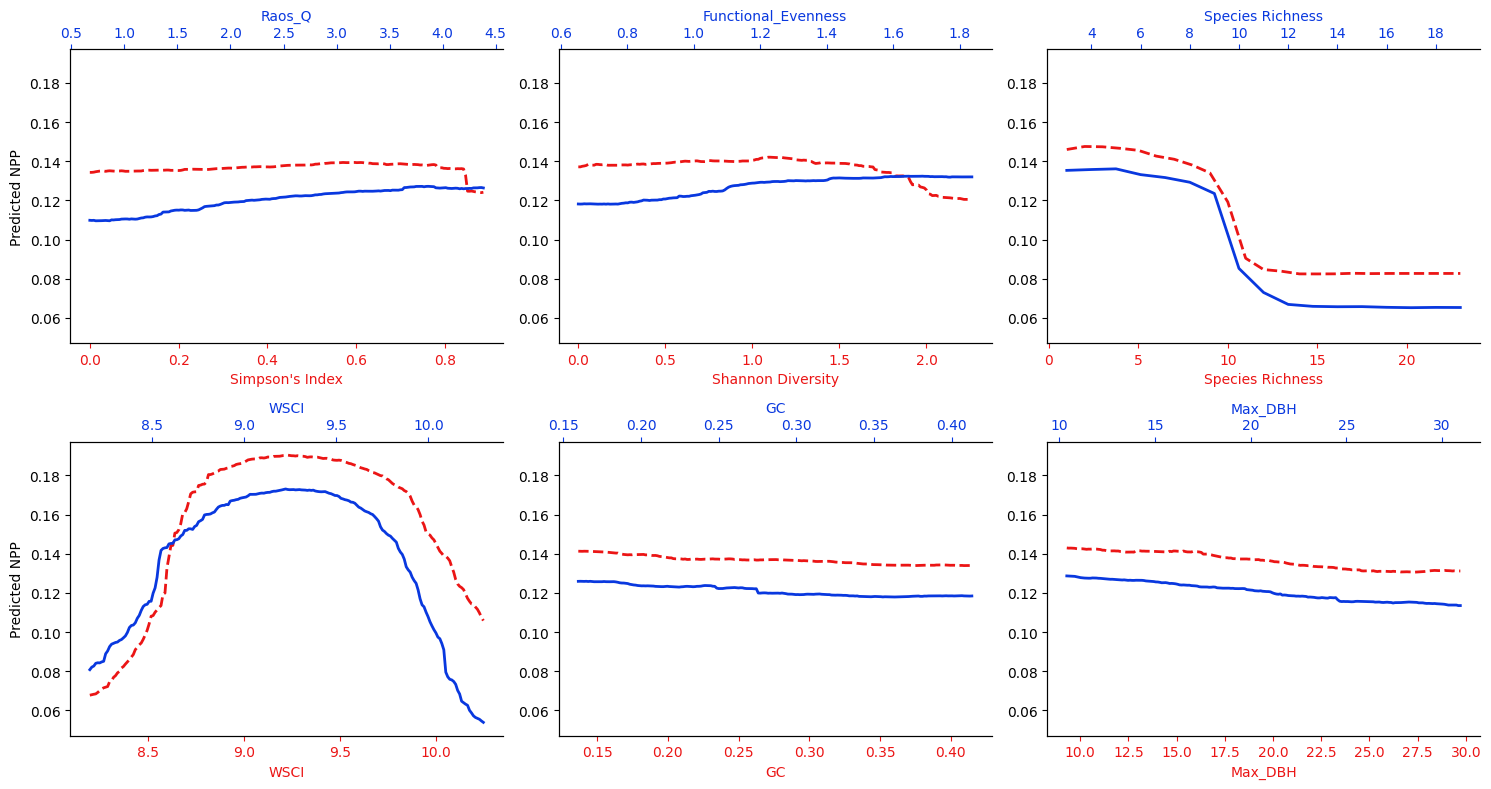

In [26]:
from sklearn.inspection import partial_dependence
import matplotlib.pyplot as plt

diversity_vars_f = ['Raos_Q', 'Functional_Evenness', 'Species Richness', 'WSCI', 'GC', 'Max_DBH']
diversity_vars_s = ["Simpson's Index", 'Shannon Diversity', 'Species Richness', 'WSCI', 'GC', 'Max_DBH']

paired_vars = list(zip(diversity_vars_f, diversity_vars_s))

colors_f = "#0938df"
colors_s = "#eb1515"

# 2 rows x 3 cols
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flatten()  # flatten to iterate easily

for ax, (f_var, s_var) in zip(axes_flat, paired_vars):

    pd_f = partial_dependence(fd_reg, fX_test, features=[f_var], grid_resolution=200)
    pd_s = partial_dependence(sd_reg, sX_test, features=[s_var], grid_resolution=200)

    x_f = pd_f["grid_values"][0]
    x_s = pd_s["grid_values"][0]
    y_f = pd_f["average"][0]
    y_s = pd_s["average"][0]

    # ── Bottom x-axis: species diversity ──
    ax.plot(x_s, y_s, color=colors_s, linewidth=2, linestyle="--")
    ax.set_xlabel(s_var, color=colors_s)
    ax.tick_params(axis="x", colors=colors_s)

    # ── Top x-axis: functional diversity ──
    ax_top = ax.twiny()
    ax_top.plot(x_f, y_f, color=colors_f, linewidth=2)
    ax_top.set_xlabel(f_var, color=colors_f)
    ax_top.tick_params(axis="x", colors=colors_f)

    # y label only on leftmost column
    ax.set_ylabel("Predicted NPP" if ax in axes[:, 0] else "")
    ax.spines[["right"]].set_visible(False)
    ax_top.spines[["right"]].set_visible(False)

# Shared y limits
all_ylims = [axes_flat[i].get_ylim() for i in range(len(paired_vars))]
global_ymin = min(l[0] for l in all_ylims)
global_ymax = max(l[1] for l in all_ylims)
for ax in axes_flat[:len(paired_vars)]:
    ax.set_ylim(global_ymin, global_ymax)

plt.tight_layout()
plt.show()

In [ ]:
# Compute pairwise SHAP interaction values — slow but exact
shap_interaction = fexplainer.shap_interaction_values(fX_test)

# Plot interaction between two specific features
feat1_idx = list(fX_test.columns).index("Raos_Q")
feat2_idx = list(fX_test.columns).index("Functional_Evenness")

shap.summary_plot(
    shap_interaction[:, feat1_idx, :],  # interaction of feat1 with all others
    fX_test
)